# Customer Churn Prediction Project
## Task 3: Exploratory Data Visualization


Using the wrangled dataset from Task 2 (`churn_wrangled.csv`, 9,343 established customers,
tenure > 12 months).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(r"C:\Users\mfana\CDAM_09-26_IP028_CustomerChurnPrediction_Kinyua\data\churn_wrangled.csv")
df["Churn_Label"] = df["Churn"].map({0: "Retained", 1: "Churned"})
df.head()

,Customer_ID,Age,Gender,Employment_Status,Account_Type,Tenure_Months,Number_of_Products,Avg_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Churn,Total_Digital_Usage,Balance_per_Product,Churn_Label
0,CUST2463,32,Male,Employed,Current,13,2,57001,19,6,10,0,0.97,1,16,28500.5,Churned
1,CUST2511,45,Male,Employed,Current,88,1,24533,14,5,9,0,0.89,0,14,24533.0,Retained
2,CUST2227,29,Female,Employed,Savings,151,3,212133,16,11,7,1,0.71,0,18,70711.0,Retained
3,CUST0526,49,Female,Employed,Savings,118,2,94045,22,12,8,0,0.89,0,20,47022.5,Retained
4,CUST0195,33,Female,Employed,Savings,108,1,137693,15,7,8,0,0.64,0,15,137693.0,Retained


## 1. Histogram — Distribution of Average Balance

**Why this graph:** A histogram is the standard way to see the *shape* of a single numeric
variable's distribution — whether it's symmetric, skewed, or has multiple peaks


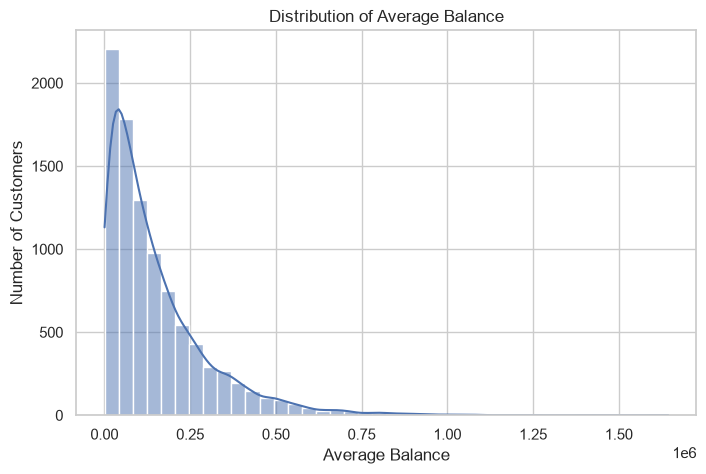

Skewness: 2.09


In [2]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Avg_Balance"], bins=40, kde=True, color="#4C72B0")
plt.title("Distribution of Average Balance")
plt.xlabel("Average Balance")
plt.ylabel("Number of Customers")
plt.show()

print(f"Skewness: {df['Avg_Balance'].skew():.2f}")

**Interpretation:** The distribution is strongly right-skewed (skewness ≈ 2.09) — most
customers hold balances under roughly 200,000, but a long tail of high-balance customers
stretches out to over 1.6 million. This is typical of financial data (a small number of
wealthy customers) and means the mean balance is a misleading "typical" figure — the median
is more representative. 


## 2. Boxplot — Average Balance by Churn Status

**Why this graph:** Boxplots are ideal for comparing a numeric variable's spread and outliers
*across groups* 


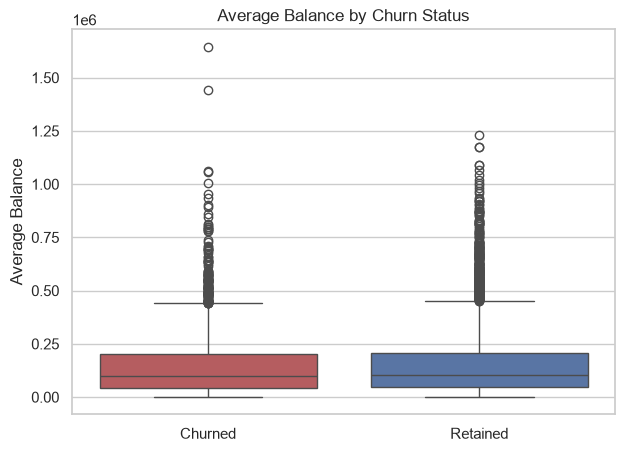

In [3]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn_Label", y="Avg_Balance", hue="Churn_Label",
            palette={"Retained": "#4C72B0", "Churned": "#C44E52"}, legend=False)
plt.title("Average Balance by Churn Status")
plt.xlabel("")
plt.ylabel("Average Balance")
plt.show()

**Interpretation:** Median balances are nearly identical between the two groups, and both
have a similar spread of high-balance outliers above the whiskers. **Unusual observation:** balance alone does **not** separate churners from retained
customers, contradicting an intuitive assumption that high-balance customers are "safer."


## 3. Scatter Plot — Digital Usage vs Average Balance

**Why this graph:** Scatter plots reveal the relationship *between two continuous variables*,
and colouring by churn lets us see if any combination of the two separates churners visually


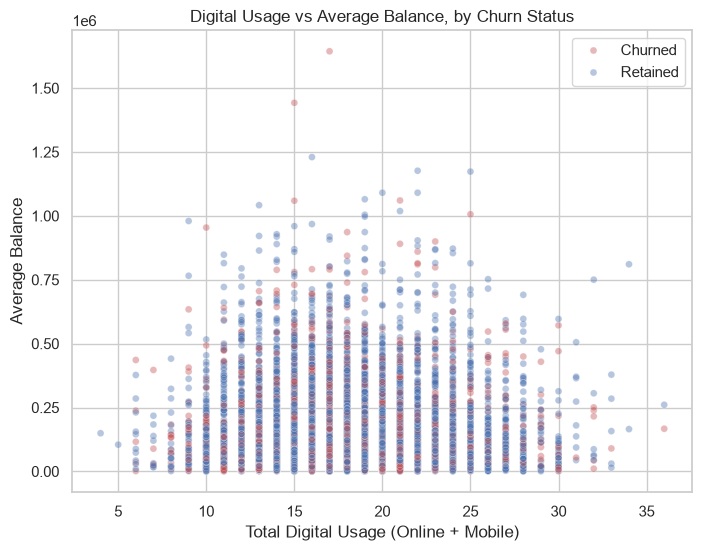

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Total_Digital_Usage", y="Avg_Balance", hue="Churn_Label",
                 palette={"Retained": "#4C72B0", "Churned": "#C44E52"}, alpha=0.4, s=25)
plt.title("Digital Usage vs Average Balance, by Churn Status")
plt.xlabel("Total Digital Usage (Online + Mobile)")
plt.ylabel("Average Balance")
plt.legend(title="")
plt.show()

**Interpretation:** There's no visible relationship between digital usage and balance
 and churned customers (red) are scattered evenly throughout rather than clustering in one corner. 
**Unusual observation:** the complete absence of a pattern here reinforces that churn in this dataset isn't driven by a simple
two-variable interaction — it likely depends on a combination of more  factors


## 4. Bar Chart — Churn Rate by Employment Status

**Why this graph:** Bar charts are the right tool for comparing a summary statistic 

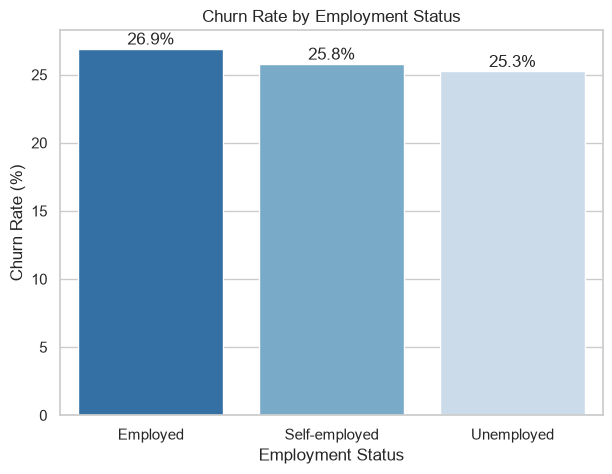

In [5]:
churn_by_employment = df.groupby("Employment_Status")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_by_employment.index, y=churn_by_employment.values, hue=churn_by_employment.index,
            palette="Blues_r", legend=False)
plt.title("Churn Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_employment.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.show()

**Interpretation:** Churn rate is fairly flat across employment groups — Employed
customers churn only marginally more (≈26.9%) than Self-employed (≈25.8%) or Unemployed
(≈25.3%). 


## 5. Pie Chart — Overall Churn Proportion

**Why this graph:** A pie chart is appropriate here specifically because we're showing parts
of a single whole (the entire customer base split into two outcomes)


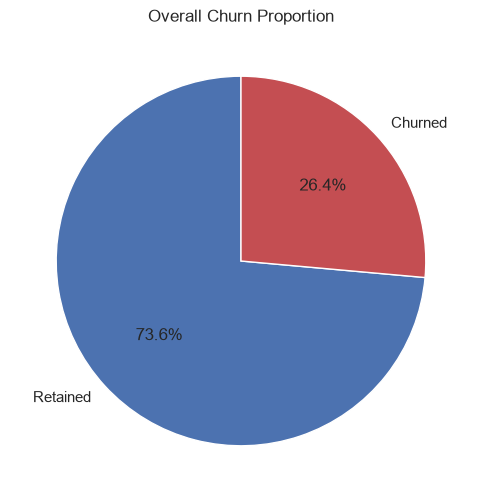

In [6]:
churn_counts = df["Churn_Label"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#C44E52"], startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.title("Overall Churn Proportion")
plt.show()

**Interpretation:** About 26.4% of established customers have churned versus 73.6%
retained. There is probably a class imbalance

## 6. Correlation Heatmap 

**Why this graph:** A heatmap lets us scan relationships between *all* numeric variables at
once, rather than checking pairs one by one and it is  efficient for spotting which features might
carry signal for the model and which are redundant with each other.


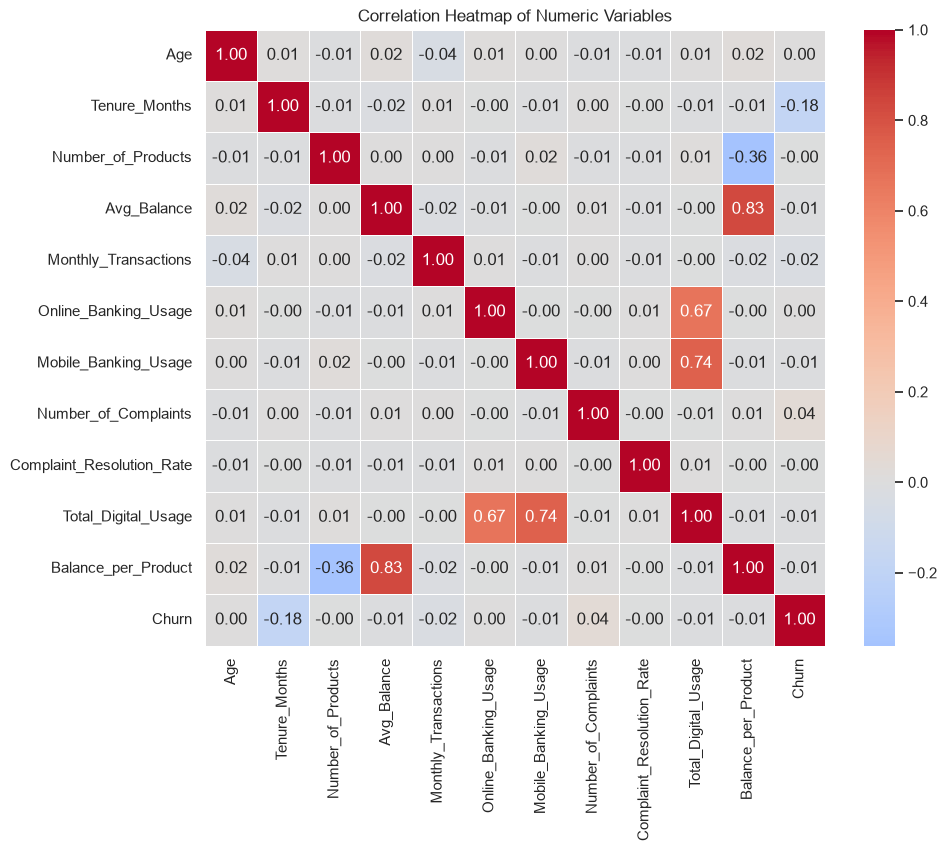

In [7]:
numeric_cols = ["Age", "Tenure_Months", "Number_of_Products", "Avg_Balance",
                 "Monthly_Transactions", "Online_Banking_Usage", "Mobile_Banking_Usage",
                 "Number_of_Complaints", "Complaint_Resolution_Rate",
                 "Total_Digital_Usage", "Balance_per_Product", "Churn"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

**Interpretation:** Every correlation with `Churn` is weak — the strongest is
`Tenure_Months` at about **-0.18**, meaning longer-tenured customers churn somewhat less
often. All other variables sit close to zero. **Unusual
observation:** `Online_Banking_Usage` and `Mobile_Banking_Usage` are also not strongly
correlated with each other, meaning they capture genuinely different customer behaviour
rather than being redundant.


## 7. Pair Plot — Key Numeric Variables by Churn

**Why this graph:** A pair plot extends the scatter-plot idea across several variables at
once, showing every pairwise relationship plus each variable's own distribution on the
diagonal — useful for spotting patterns a single scatter plot would miss


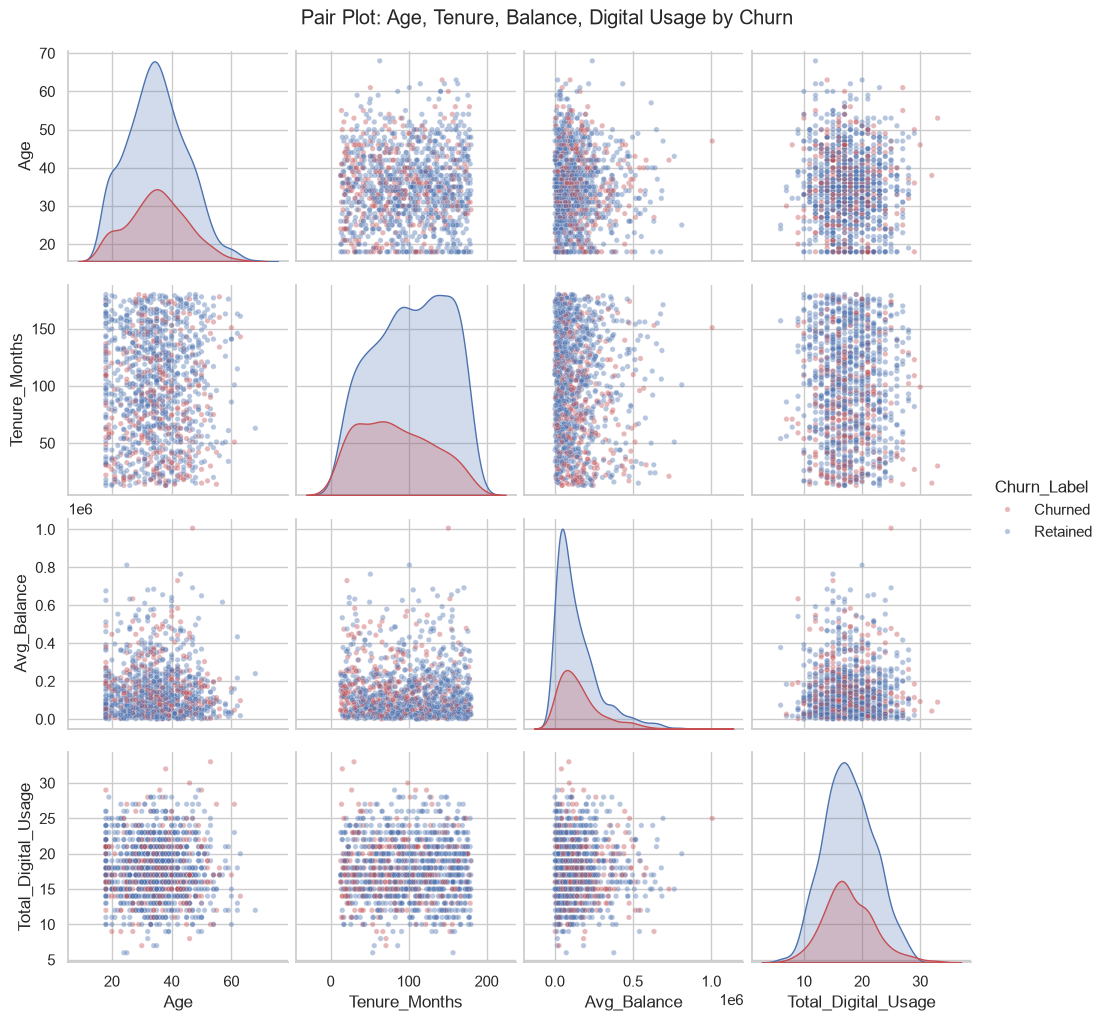

In [8]:
sample = df.sample(1200, random_state=42)

pair_cols = ["Age", "Tenure_Months", "Avg_Balance", "Total_Digital_Usage", "Churn_Label"]
g = sns.pairplot(sample[pair_cols], hue="Churn_Label",
                  palette={"Retained": "#4C72B0", "Churned": "#C44E52"},
                  diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g.fig.suptitle("Pair Plot: Age, Tenure, Balance, Digital Usage by Churn", y=1.02)
plt.show()

**Interpretation:** The diagonal KDE plots show retained and churned customers overlap
almost completely on Age, Balance, and Digital Usage and only the `Tenure_Months` diagonal shows
a visible leftward shift for churned customers (their distribution leans toward shorter
tenure). None of the scatter panels show a separable cluster. 


## 8. Violin Plot — Tenure Distribution by Churn Status

**Why this graph:** A violin plot combines a boxplot with a density curve, showing not just
the median and spread but the full *shape* of the distribution and useful here to see exactly
*when* in a customer's lifecycle churn risk is highest.


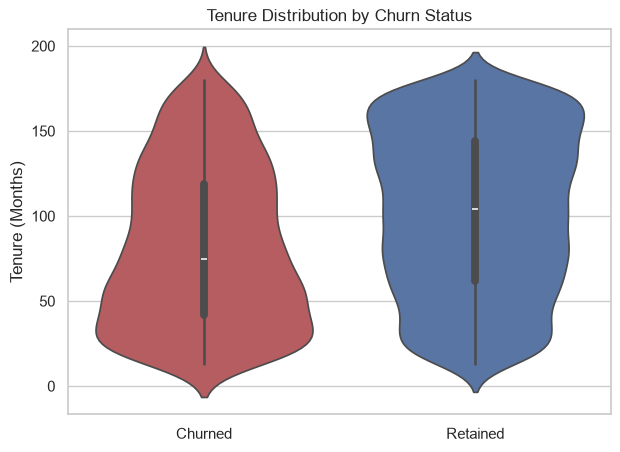

In [9]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Churn_Label", y="Tenure_Months", hue="Churn_Label",
               palette={"Retained": "#4C72B0", "Churned": "#C44E52"}, legend=False)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("")
plt.ylabel("Tenure (Months)")
plt.show()

**Interpretation:** The churned group's violin is visibly wider and denser in the lower
tenure range (roughly 40-120 months) and thinner at the high end, while the retained group is
more evenly spread with a bulge toward longer tenures. Median tenure for churners is about 75
months versus 104 months for retained customers. 
